## read data


In [858]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

In [859]:
train = pd.read_csv(r"train (1).csv");
test=pd.read_csv(r"test (1).csv");



In [860]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            429 non-null    str    
 1   Gender             418 non-null    str    
 2   Married            428 non-null    str    
 3   Dependents         418 non-null    str    
 4   Education          429 non-null    str    
 5   Self_Employed      411 non-null    str    
 6   ApplicantIncome    429 non-null    int64  
 7   CoapplicantIncome  429 non-null    float64
 8   LoanAmount         414 non-null    float64
 9   Loan_Amount_Term   418 non-null    float64
 10  Credit_History     397 non-null    float64
 11  Property_Area      429 non-null    str    
 12  Loan_Status        429 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 43.7 KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,429.000000,429.000000,414.000000,418.000000,397.000000
mean,5463.286713,1591.013520,146.867150,338.698565,0.848866
std,6009.568717,2665.828587,86.215588,69.079526,0.358631
min,150.000000,0.000000,17.000000,12.000000,0.000000
25%,2833.000000,0.000000,100.000000,360.000000,1.000000
50%,3858.000000,1041.000000,128.000000,360.000000,1.000000
75%,5923.000000,2330.000000,167.500000,360.000000,1.000000
max,81000.000000,33837.000000,700.000000,480.000000,1.000000


In [861]:
train.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002788,Male,Yes,0,Not Graduate,No,2454,2333.0,181.0,360.0,0.0,Urban,N
1,LP002950,Male,Yes,0,Not Graduate,NaN,2894,2792.0,155.0,360.0,1.0,Rural,Y
2,LP001868,Male,No,0,Graduate,No,2060,2209.0,134.0,360.0,1.0,Semiurban,Y
3,LP002587,Male,Yes,0,Not Graduate,No,2600,1700.0,107.0,360.0,1.0,Rural,Y
4,LP002716,Male,No,0,Not Graduate,No,6783,0.0,130.0,360.0,1.0,Semiurban,Y


In [862]:
train.isnull().sum()

Loan_ID               0
Gender               11
Married               1
Dependents           11
Education             0
Self_Employed        18
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           15
Loan_Amount_Term     11
Credit_History       32
Property_Area         0
Loan_Status           0
dtype: int64

# data cleaning

## missing values

In [863]:
for df in [train, test]:
    df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
    df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
    df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
    df['Credit_History'] = df['Credit_History'].fillna(1)

    df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
    df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

In [864]:
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])

In [865]:
print(train.isnull().sum())

Loan_ID               0
Gender                0
Married               0
Dependents           11
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64


In [866]:
train.duplicated().sum()
test.duplicated().sum()

np.int64(0)

In [867]:
train.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002788,Male,Yes,0,Not Graduate,No,2454,2333.0,181.0,360.0,0.0,Urban,N
1,LP002950,Male,Yes,0,Not Graduate,No,2894,2792.0,155.0,360.0,1.0,Rural,Y
2,LP001868,Male,No,0,Graduate,No,2060,2209.0,134.0,360.0,1.0,Semiurban,Y
3,LP002587,Male,Yes,0,Not Graduate,No,2600,1700.0,107.0,360.0,1.0,Rural,Y
4,LP002716,Male,No,0,Not Graduate,No,6783,0.0,130.0,360.0,1.0,Semiurban,Y


In [868]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            429 non-null    str    
 1   Gender             429 non-null    str    
 2   Married            429 non-null    str    
 3   Dependents         418 non-null    str    
 4   Education          429 non-null    str    
 5   Self_Employed      429 non-null    str    
 6   ApplicantIncome    429 non-null    int64  
 7   CoapplicantIncome  429 non-null    float64
 8   LoanAmount         429 non-null    float64
 9   Loan_Amount_Term   429 non-null    float64
 10  Credit_History     429 non-null    float64
 11  Property_Area      429 non-null    str    
 12  Loan_Status        429 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 43.7 KB


In [869]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,429.000000,429.000000,429.000000,429.000000,429.000000
mean,5463.286713,1591.013520,146.207459,339.244755,0.860140
std,6009.568717,2665.828587,84.762375,68.269314,0.347247
min,150.000000,0.000000,17.000000,12.000000,0.000000
25%,2833.000000,0.000000,100.000000,360.000000,1.000000
50%,3858.000000,1041.000000,128.000000,360.000000,1.000000
75%,5923.000000,2330.000000,164.000000,360.000000,1.000000
max,81000.000000,33837.000000,700.000000,480.000000,1.000000


## Encoding

In [870]:
le = LabelEncoder()

cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

for col in cols:
    train[col] = le.fit_transform(train[col])

In [871]:
train['Loan_Status'] = train['Loan_Status'].astype(str).str.strip()
train['Loan_Status'] = train['Loan_Status'].map({'Y': 1, 'N': 0})

In [872]:
train['Credit_History'] = train['Credit_History'].fillna(1)
test['Credit_History'] = test['Credit_History'].fillna(1)

## drop 

In [873]:
train.drop('Loan_ID', axis=1, inplace=True)
train.drop('Dependents', axis=1, inplace=True)

In [874]:
## feature engineering
train['TotalIncome'] = train['ApplicantIncome'] + train['CoapplicantIncome']
train['Income_Log'] = np.log(train['TotalIncome'] + 1)
train['LoanAmount_Log'] = np.log(train['LoanAmount'] + 1)
train['Debt_Ratio'] = train['LoanAmount'] / (train['TotalIncome'] + 1)
train['EMI'] = train['LoanAmount'] / train['Loan_Amount_Term']

## EDA

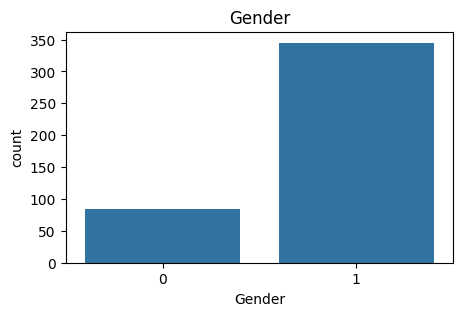

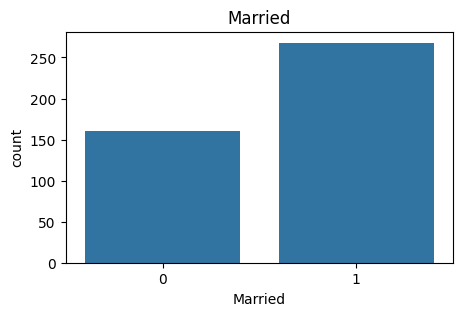

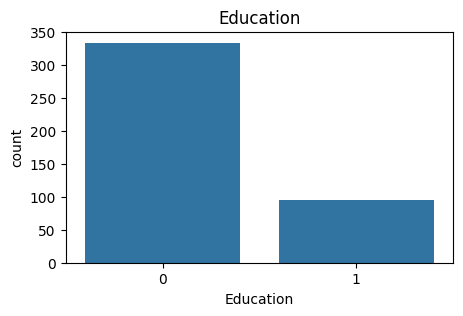

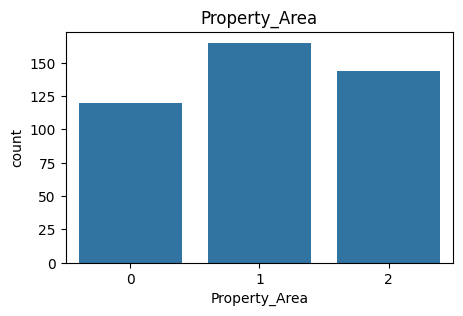

In [875]:
for col in ['Gender', 'Married', 'Education', 'Property_Area']:
    plt.figure(figsize=(5,3))
    sns.countplot(x=train[col])
    plt.title(col)
    plt.show()

## Split Data

In [876]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [877]:
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [878]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Train Model (logistic)

In [879]:
model = LogisticRegression(
    C=0.5,
    class_weight='balanced',  # 🔥 مهم جدًا
    max_iter=1000
)

In [880]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [881]:
#evalution
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.813953488372093
Confusion Matrix:
 [[15  9]
 [ 7 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.62      0.65        24
           1       0.86      0.89      0.87        62

    accuracy                           0.81        86
   macro avg       0.77      0.76      0.76        86
weighted avg       0.81      0.81      0.81        86



In [882]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5)
print(scores.mean())

0.7599726402188782


In [883]:
## antoher model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [884]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [885]:
## evalution
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.8488372093023255
XGBoost Confusion Matrix:
 [[18  6]
 [ 7 55]]
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.75      0.73        24
           1       0.90      0.89      0.89        62

    accuracy                           0.85        86
   macro avg       0.81      0.82      0.81        86
weighted avg       0.85      0.85      0.85        86



In [886]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X_scaled, y, cv=5)
print(scores.mean())

0.7948837209302326


In [887]:
## another model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [888]:
## evalution
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf)) 
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8488372093023255
Random Forest Confusion Matrix:
 [[13 11]
 [ 2 60]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.54      0.67        24
           1       0.85      0.97      0.90        62

    accuracy                           0.85        86
   macro avg       0.86      0.75      0.78        86
weighted avg       0.85      0.85      0.84        86



In [889]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_scaled, y, cv=5)
print(scores.mean())

0.813515731874145


## test

In [890]:

# fill missing
for col in cat_cols:
    test[col] = test[col].fillna(test[col].mode()[0])

test['LoanAmount'] = test['LoanAmount'].fillna(test['LoanAmount'].median())
test['Loan_Amount_Term'] = test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].mode()[0])

In [891]:
le = LabelEncoder()

cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

for col in cols:
    test[col] = le.fit_transform(test[col])

In [892]:
## drop
test.drop('Loan_ID', axis=1, inplace=True)
test.drop('Dependents', axis=1, inplace=True)

In [893]:
## feature engineering
test['TotalIncome'] = test['ApplicantIncome'] + test['CoapplicantIncome']
test['Income_Log'] = np.log(test['TotalIncome'] + 1)
test['LoanAmount_Log'] = np.log(test['LoanAmount'] + 1)
test['Debt_Ratio'] = test['LoanAmount'] / (test['TotalIncome'] + 1)
test['EMI'] = test['LoanAmount'] / test['Loan_Amount_Term']

In [894]:
test_scaled = scaler.transform(test)

In [895]:
sample = pd.read_csv("sample_submission (1).csv")

In [896]:
print(set(rf.predict(test_scaled)))

{np.int64(0), np.int64(1)}


In [900]:
print(sample.head())
print(sample.isnull().sum())
print(set(sample['Loan_Status']))
print(len(sample), len(preds))

    Loan_ID  Loan_Status
0  LP002139            1
1  LP002223            1
2  LP001570            1
3  LP002978            1
4  LP001478            1
Loan_ID        0
Loan_Status    0
dtype: int64
{0, 1}
185 185


In [901]:
print(train.head())
print(train.columns)
print(y.value_counts())

   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       1        1          1              0             2454   
1       1        1          1              0             2894   
2       1        0          0              0             2060   
3       1        1          1              0             2600   
4       1        0          1              0             6783   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0             2333.0       181.0             360.0             0.0   
1             2792.0       155.0             360.0             1.0   
2             2209.0       134.0             360.0             1.0   
3             1700.0       107.0             360.0             1.0   
4                0.0       130.0             360.0             1.0   

   Property_Area  Loan_Status  TotalIncome  Income_Log  LoanAmount_Log  \
0              2            0       4787.0    8.473868        5.204007   
1              0            1       5686

In [907]:
import catboost
from catboost import CatBoostClassifier 
cat = CatBoostClassifier(
    iterations=800,
    depth=5,
    learning_rate=0.03,
    l2_leaf_reg=5,
    verbose=0,
    random_seed=42
)
cat.fit(X_train, y_train)

CatBoostClassifier(depth=5, iterations=800, l2_leaf_reg=5, learning_rate=0.03, random_seed=42, verbose=0)

In [909]:
cross_val_score(cat, X_scaled, y, cv=5).mean()

np.float64(0.7972366621067032)

In [908]:
preds = cat.predict(test_scaled)
sample['Loan_Status'] = preds
sample.to_csv("submission_numeric.csv", index=False)